In [41]:
classification_names = {
    0: 'clothes',
    1: 'shoe',
    2: 'bag',
    3: 'pants',
    4: 'watch'
}

In [4]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader,Dataset,random_split
from PIL import Image
import re
import torchvision.transforms as T

In [5]:
#按字母数字混合排序
def sorted_alphanum(img_names):
    #转化函数
    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda image_name: [convert(x) for x in re.split('([0-9]+)', image_name)]
    return sorted(img_names, key=alphanum_key)


#自定义数据集类型
class ImageLabelDataSet(Dataset):
    def __init__(self, image_dir, transform=None):
        self.main_dir = image_dir
        self.transform = transform
        self.image_names = sorted_alphanum(os.listdir(self.main_dir))
        self.labels = pd.read_csv('../common/fashion-labels.csv')  #读取分类标签文件 得到DataFrame
        self.label_dict = dict(zip(self.labels['id'], self.labels['target']))  #分离id和标签 得到字典

    def __len__(self):
        return len(self.image_names)

    #传入图片ID 获取数据集元素(X,y)  不是一次性加载 选择性加载 防止爆内存
    def __getitem__(self, idx):
        #1.根据索引号 获得图片完整路径
        image_loc = os.path.join(self.main_dir, self.image_names[idx])
        #2.使用PIL打开图片
        image = Image.open(image_loc).convert('RGB')
        #3.利用transform转化
        if self.transform:
            tensor_image = self.transform(image)
        else:
            raise ValueError('transform is not defined')
        #在字典中找到标签
        label = self.label_dict[idx]
        return tensor_image, label

In [6]:
#创建数据集
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
transform=T.Compose([
    T.Resize((64, 64)),
    T.ToTensor()
])
full_dataset=ImageLabelDataSet(image_dir='../common/dataset/', transform=transform)
print(full_dataset.__len__())

24853


In [7]:
#划分数据集
train_dataset,test_dataset=random_split(full_dataset,[0.75,0.25])
print(len(train_dataset))
print(len(test_dataset))

18640
6213


In [8]:
#创建dataloader
batch_size=32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,drop_last=True)#丢弃最后一批除不尽的数据
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,drop_last=False)

In [9]:
for X,y in train_loader:
    print(X.shape)
    print(y.shape)
    break

torch.Size([32, 3, 64, 64])
torch.Size([32])


In [10]:
import torch.nn as nn
#定义模型
class Classifier(nn.Module):
    def __init__(self,n_classes=5):
        super(Classifier, self).__init__()
        self.model=nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(in_features=16*16*16, out_features=n_classes),
        )
        # #卷积层
        # self.conv1 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1)
        # self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)
        # #通用池化层
        # self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # #全连接层
        # self.linear = nn.Linear(in_features=16*16*16, out_features=5)

    def forward(self,x):
        # x=torch.relu(self.conv1(x))
        # #print(f'first conv1: {x.shape}')
        # x=self.pool(x)
        # #print(f'pool conv1: {x.shape}')
        # x=torch.relu(self.conv2(x))
        # #print(f'pool conv2: {x.shape}')
        # x=self.pool(x)
        # #print(f'pool conv2: {x.shape}')
        #
        # #扁平化
        # x=x.reshape(x.shape[0],-1)
        # #print(f'reshape: {x.shape}')
        # x = self.linear(x)
        # #print(f'linear: {x.shape}')
        x=self.model(x)
        return x


In [18]:
model=Classifier(n_classes=5)
print(model)

Classifier(
  (model): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=4096, out_features=5, bias=True)
  )
)


In [19]:
data_iter=iter(train_loader)
x,y=next(data_iter)
print(x.shape)
print(y.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32])


In [20]:
output=model(x)
print(output.shape)

torch.Size([32, 5])


In [24]:
#训练
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epoch_num = 5
model.to(device)
for epoch in range(epoch_num):
    print("\n" + "=" * 50)
    print(f"🧩 Epoch [{epoch + 1}/{epoch_num}] 开始，在设备: {device}")
    model.train()

    total_loss = 0.0
    batch_count = len(train_loader)

    for batch_idx, (x, y) in enumerate(train_loader, start=1):
        # 移动数据到 GPU 或 CPU
        x = x.to(device)
        y = y.to(device)

        # 前向传播
        output = model(x)
        loss_val = loss_fn(output, y)

        # 反向传播 + 更新参数
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        total_loss += loss_val.item()

        # 每隔一定 batch 打印进度
        if batch_idx % 100 == 0 or batch_idx == batch_count:
            print(f"📊 [Epoch {epoch + 1}/{epoch_num}] Batch {batch_idx}/{batch_count} "
                  f"→ Loss: {loss_val.item():.4f}")

    # 计算该 epoch 平均损失
    this_loss = total_loss / batch_count
    print(f"✅ Epoch [{epoch + 1}/{epoch_num}] 完成，平均损失: {this_loss:.4f}")

    # 打印显存使用情况（若使用 GPU）
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024 ** 2
        reserved = torch.cuda.memory_reserved() / 1024 ** 2
        total = torch.cuda.get_device_properties(0).total_memory / 1024 ** 2
        print(f"💻 GPU 显存使用: 已分配 {allocated:.1f}MB / 已缓存 {reserved:.1f}MB / 总显存 {total:.1f}MB")

print("\n🎯 训练结束！所有 epoch 已完成。")



🧩 Epoch [1/5] 开始，在设备: cuda
📊 [Epoch 1/5] Batch 100/582 → Loss: 0.3959
📊 [Epoch 1/5] Batch 200/582 → Loss: 0.2039
📊 [Epoch 1/5] Batch 300/582 → Loss: 0.1083
📊 [Epoch 1/5] Batch 400/582 → Loss: 0.0225
📊 [Epoch 1/5] Batch 500/582 → Loss: 0.0347
📊 [Epoch 1/5] Batch 582/582 → Loss: 0.5509
✅ Epoch [1/5] 完成，平均损失: 0.0822
💻 GPU 显存使用: 已分配 19.7MB / 已缓存 44.0MB / 总显存 8191.5MB

🧩 Epoch [2/5] 开始，在设备: cuda
📊 [Epoch 2/5] Batch 100/582 → Loss: 0.2964
📊 [Epoch 2/5] Batch 200/582 → Loss: 0.0162
📊 [Epoch 2/5] Batch 300/582 → Loss: 0.0563
📊 [Epoch 2/5] Batch 400/582 → Loss: 0.0009
📊 [Epoch 2/5] Batch 500/582 → Loss: 0.1704
📊 [Epoch 2/5] Batch 582/582 → Loss: 0.0754
✅ Epoch [2/5] 完成，平均损失: 0.0624
💻 GPU 显存使用: 已分配 19.7MB / 已缓存 44.0MB / 总显存 8191.5MB

🧩 Epoch [3/5] 开始，在设备: cuda
📊 [Epoch 3/5] Batch 100/582 → Loss: 0.0396
📊 [Epoch 3/5] Batch 200/582 → Loss: 0.0009
📊 [Epoch 3/5] Batch 300/582 → Loss: 0.0778
📊 [Epoch 3/5] Batch 400/582 → Loss: 0.0235
📊 [Epoch 3/5] Batch 500/582 → Loss: 0.0301
📊 [Epoch 3/5] Batch 582

In [25]:
#验证测试
loader_iter=iter(test_loader)
images,labels=next(loader_iter)
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32])


In [26]:
model.to(device)
images=images.to(device)
#前向传播 计算输出
outputs=model(images)
outputs=outputs.cpu().detach().numpy()
print(outputs.shape)

(32, 5)


In [27]:
images=images.permute(0,2,3,1).detach().cpu().numpy()
print(images.shape)

(32, 64, 64, 3)


1-label:pants
1-output:[-14.122195 -17.82981  -21.096458  11.969574  -9.613814]
1-prediction:pants

2-label:clothes
2-output:[  0.604579  -7.551168  -6.708805  -4.818976 -11.008365]
2-prediction:clothes

3-label:pants
3-output:[-11.831752 -19.88587  -17.805286  10.284072 -14.057909]
3-prediction:pants

4-label:shoe
4-output:[-15.075763    7.603777   -3.7237093 -11.374021  -11.963935 ]
4-prediction:shoe

5-label:clothes
5-output:[  5.4438186  -7.833327  -16.09119    -4.091313  -20.931242 ]
5-prediction:clothes

6-label:shoe
6-output:[ -6.5687833   3.869858  -10.1974945  -5.797959   -8.22701  ]
6-prediction:shoe

7-label:shoe
7-output:[-7.6068487  2.3218968 -6.965264  -5.078743  -8.785587 ]
7-prediction:shoe

8-label:clothes
8-output:[  1.4928017 -15.022656  -10.637865  -11.808948   -7.735269 ]
8-prediction:clothes

9-label:clothes
9-output:[-3.2863643 -2.5958111 -9.578006  -5.1755614 -9.887258 ]
9-prediction:shoe

10-label:clothes
10-output:[ 0.1807222 -7.931989  -7.650195  -3.121222  -

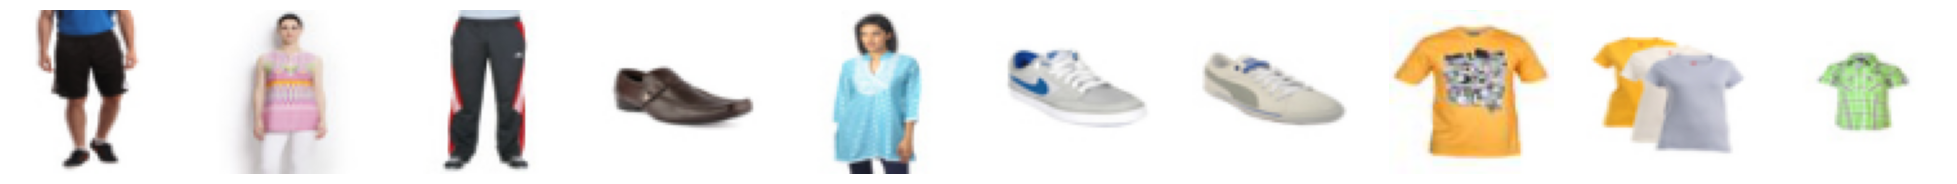

In [35]:
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,10,figsize=(25,4))
for i ,ax in enumerate(axes):
    ax.imshow(images[i])
    ax.axis('off')
    #打印真实分类标签
    print(f'{i+1}-label:{classification_names[int(labels[i])]}')
    #打印预测值
    y_pred=outputs[i]
    print(f'{i+1}-output:{y_pred}')
    #打印预测分类
    class_pred=np.argmax(y_pred)
    print(f'{i+1}-prediction:{classification_names[class_pred]}')
    print()
plt.show()

In [40]:
#计算准确率
model.eval()
right_num=0
with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_loader, start=1):
        x = x.to(device)
        y = y.to(device)

        # 前向传播
        output = model(x)
        y_pred = output.argmax(dim=1)

        # 累计预测正确数量
        right_num += y_pred.eq(y).sum().item()

        # 每隔一定 batch 打印一次测试进度
        if batch_idx % 100 == 0 or batch_idx == len(test_loader):
            print(f"📊 Batch {batch_idx}/{len(test_loader)} has been tested..")

# 计算整体准确率
accuracy = right_num / len(test_dataset)
print(f'accuracy: {accuracy*100:.2f}%')


📊 Batch 100/195 has been tested..
📊 Batch 195/195 has been tested..
accuracy: 98.39%
